# Cell 1

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import scipy.io
import matplotlib.pyplot as plt

MAT_NAME    = "photodiode_test_changing_lenght_20261007_2.mat"
MARKER_CH   = -1       # last column  = LSL marker
PHOTO_CH    = -2       # second-last  = photodiode / g.TRIGbox digital input
FLASH_CODE, CAL_DARK, CAL_LIGHT, BLOCK_CODE = 20, 5, 6, 7
ON_START_MS = 100.0    # duration of flash 1, as set in the run dialog
ON_STEP_MS  = 1000 / 60  # increase per flash after rounding to frames (16.67 ms at 60 and 120 Hz)
MAX_GAP     = 0.030    # s; gaps shorter than this inside a pulse are bridged
MIN_PULSE   = 0.030    # s; pulses shorter than this are ignored

mat_path = next((p for p in (Path("../data") / MAT_NAME, Path("data") / MAT_NAME) if p.exists()), None)
assert mat_path is not None, f"{MAT_NAME} not found in ../data or data"
if h5py.is_hdf5(mat_path):                        # MATLAB v7.3 = HDF5
    with h5py.File(mat_path, "r") as f:
        eeg = f["EEG_data"][()]
else:
    eeg = scipy.io.loadmat(mat_path)["EEG_data"]
eeg = np.asarray(eeg, dtype=float)
if eeg.shape[0] < eeg.shape[1]:                   # make it samples x channels
    eeg = eeg.T

t = eeg[:, 0]
fs = 1.0 / np.median(np.diff(t))
marker = np.rint(eeg[:, MARKER_CH]).astype(int)
photo_raw = eeg[:, PHOTO_CH]
print(f"{mat_path}  ->  {eeg.shape[0]} samples x {eeg.shape[1]} columns, "
      f"{t[-1] - t[0]:.1f} s, fs = {fs:.1f} Hz (1 sample = {1000 / fs:.2f} ms)")
for c in range(eeg.shape[1] - 3, eeg.shape[1]):
    u = np.unique(eeg[:, c])
    desc = f"values {u.astype(int).tolist()}" if u.size <= 12 else f"{u.size} distinct values"
    print(f"  col {c}: min {eeg[:, c].min():.4g}, max {eeg[:, c].max():.4g}, {desc}")

../data/photodiode_test_changing_lenght_20261007_2.mat  ->  83646 samples x 67 columns, 139.4 s, fs = 600.0 Hz (1 sample = 1.67 ms)
  col 64: min -3.563e+05, max -3.562e+05, 1433 distinct values
  col 65: min 0, max 6.554e+04, values [0, 65536]
  col 66: min 0, max 255, values [0, 5, 6, 7, 9, 20, 255]


# Cell 2

In [2]:
def pulses(mask):
    """Runs of True in `mask` -> DataFrame(onset_s, width_ms). Short gaps are bridged, short runs dropped."""
    d = np.diff(np.r_[0, mask.astype(int), 0])
    on, off = np.flatnonzero(d == 1), np.flatnonzero(d == -1)
    if on.size == 0:
        return pd.DataFrame({"onset_s": [], "width_ms": []})
    keep = np.r_[True, (on[1:] - off[:-1]) / fs > MAX_GAP]        # start of a new pulse
    on, off = on[keep], off[np.r_[keep[1:], True]]
    ok = (off - on) / fs >= MIN_PULSE
    return pd.DataFrame({"onset_s": t[on[ok]], "width_ms": (off[ok] - on[ok]) / fs * 1000})

# markers
codes = [c for c in np.unique(marker) if c != 0]
ev = pd.concat([pulses(marker == c).assign(code=c) for c in codes]).sort_values("onset_s").reset_index(drop=True)
print(ev.groupby("code").agg(n=("code", "size"), first_s=("onset_s", "min"),
                             width_min=("width_ms", "min"), width_max=("width_ms", "max")).round(1).to_string())
mk = ev[ev.code == FLASH_CODE].reset_index(drop=True)
mk["flash"] = np.arange(1, len(mk) + 1)           # markers are complete, so order = flash number
mk["intended_ms"] = ON_START_MS + (mk.flash - 1) * ON_STEP_MS
t_block = ev.loc[ev.code == BLOCK_CODE, "onset_s"].min()

# photodiode: try both polarities and keep the one whose pulse widths form the rising ramp
thr = (photo_raw.min() + photo_raw.max()) / 2
photo_hi = photo_raw > thr
max_w = mk.intended_ms.max() * 1.6

def flash_pulses(mask):
    p = pulses(mask)
    return p, p[(p.onset_s > t_block) & (p.width_ms <= max_w)].reset_index(drop=True)

def ramp_score(p):                                # share of neighbours that differ by about one step
    dw = np.diff(p.width_ms)
    return np.mean((dw > 0.3 * ON_STEP_MS) & (dw < 1.8 * ON_STEP_MS)) if len(dw) else 0.0

cands = {"HIGH": flash_pulses(photo_hi), "LOW": flash_pulses(~photo_hi)}
scores = {k: ramp_score(v[1]) for k, v in cands.items()}
pol = max(scores, key=scores.get)
square_on = photo_hi if pol == "HIGH" else ~photo_hi
pd_all, pdp = cands[pol]
print(f"\nRamp score (share of neighbouring pulses one step apart): "
      f"HIGH {scores['HIGH']:.0%} | LOW {scores['LOW']:.0%}")
print(f"Polarity: square ON = photodiode {pol}")

print(f"\nFlash markers: {len(mk)}   photodiode pulses in the flash block: {len(pdp)}")
print(f"Marker widths:     {mk.width_ms.min():.0f} to {mk.width_ms.max():.0f} ms "
      f"(intended {mk.intended_ms.min():.0f} to {mk.intended_ms.max():.0f})")
print(f"Photodiode widths: {pdp.width_ms.min():.0f} to {pdp.width_ms.max():.0f} ms")
real_s = (mk.intended_ms.sum() / 1000) + 0.5 * (len(mk) - 1)
print(f"Flash block length: recorded {mk.onset_s.iloc[-1] - mk.onset_s.iloc[0]:.1f} s between first and last marker; "
      f"expected about {real_s - mk.intended_ms.iloc[-1] / 1000:.0f} s if the model keeps real time")

        n  first_s  width_min  width_max
code                                    
5       2     13.1       83.3       83.3
6       1     15.6       81.7       81.7
7       1     20.5       83.3       83.3
9       1      6.2       76.7       76.7
20    100     22.1       83.3     1430.0

Ramp score (share of neighbouring pulses one step apart): HIGH 91% | LOW 4%
Polarity: square ON = photodiode HIGH

Flash markers: 100   photodiode pulses in the flash block: 78
Marker widths:     83 to 1430 ms (intended 100 to 1750)
Photodiode widths: 135 to 1768 ms
Flash block length: recorded 113.7 s between first and last marker; expected about 140 s if the model keeps real time


# Cell 3

In [3]:
def width_fit(idx, width):
    b, a = np.polyfit(idx, width, 1)
    return a, b

a_m, b_m = width_fit(mk.flash, mk.width_ms)

# photodiode: chain neighbouring pulses (each should be one step longer than the previous one)
dw = np.diff(pdp.width_ms)
near = dw[(dw > 0.3 * ON_STEP_MS) & (dw < 1.8 * ON_STEP_MS)]
b0 = np.median(near) if near.size else ON_STEP_MS
rel = np.r_[0, np.cumsum(np.rint(dw / b0))].astype(int)        # index relative to the first pulse
a_p, b_p = width_fit(rel, pdp.width_ms)

def number_in_order(x):
    """Whole flash numbers closest to x that also increase from one pulse to the next."""
    offs = np.arange(-2, 3)
    g = np.rint(x)[:, None] + offs[None, :]                     # candidate numbers per pulse
    cost = (g - x[:, None]) ** 2
    best, back = cost[0].copy(), np.zeros(g.shape, int)
    for j in range(1, len(x)):
        ok = g[j - 1][:, None] < g[j][None, :]                  # previous number must be smaller
        tot = best[:, None] + np.where(ok, 0.0, 25.0)           # out-of-order costs a penalty
        back[j] = tot.argmin(axis=0)
        best = tot.min(axis=0) + cost[j]
    path = [best.argmin()]
    for j in range(len(x) - 1, 0, -1):
        path.append(back[j][path[-1]])
    return g[np.arange(len(x)), path[::-1]].astype(int)

pdp["rel"] = number_in_order(((pdp.width_ms - a_p) / b_p).to_numpy())
good = pdp[~pdp.rel.duplicated(keep=False)]

# the first pulse is flash 1 + k; choose k so that the delay is most consistent across the run
def pair(k, src=None):
    src = good if src is None else src
    m = src.assign(flash=src.rel - good.rel.min() + 1 + k).merge(
        mk[["flash", "onset_s", "width_ms", "intended_ms"]], on="flash", suffixes=("_pd", "_mk"))
    m["delay_ms"] = (m.onset_s_pd - m.onset_s_mk) * 1000
    return m

def trend(m):                                                   # robust straight line through the delays
    keep = np.ones(len(m), bool)
    for _ in range(3):
        c = np.polyfit(m.onset_s_mk[keep], m.delay_ms[keep], 1)
        r = m.delay_ms - np.polyval(c, m.onset_s_mk)
        mad = 1.4826 * np.median(np.abs(r - np.median(r))) + 1e-9
        keep = (np.abs(r - np.median(r)) < 4 * mad).to_numpy()
    return c, r, mad

scan = []
for k in range(-(good.rel.max() - good.rel.min()), len(mk) + 1):
    m = pair(k)
    if len(m) >= max(8, 0.5 * len(good)):
        scan.append((trend(m)[2], k, len(m)))
assert scan, "No alignment found: photodiode widths do not overlap the marker ramp. Check cell 2 output."
scan.sort()
best_spread, k_best, _ = scan[0]
pairs = pair(k_best)

# safety net: a width misread by one step shows up as a delay far from the trend -> try the neighbours
c, r, mad = trend(pairs)
fixed = 0
for i in pairs.index[np.abs(r) > 150]:
    alts = []
    for shift in (-2, -1, 1, 2):
        f = pairs.flash[i] + shift
        if 1 <= f <= len(mk) and f not in set(pairs.flash):
            mt = mk.onset_s[f - 1]
            d_alt = (pairs.onset_s_pd[i] - mt) * 1000
            alts.append((abs(d_alt - np.polyval(c, mt)), f, mt, d_alt))
    if alts and min(alts)[0] < 150:
        _, f, mt, d_alt = min(alts)
        pairs.loc[i, ["flash", "onset_s_mk", "width_ms_mk", "intended_ms", "delay_ms"]] = \
            [f, mt, mk.width_ms[f - 1], mk.intended_ms[f - 1], d_alt]
        fixed += 1
c, r, mad = trend(pairs)
outliers = pairs[np.abs(r) > 150]
pairs = pairs[np.abs(r) <= 150].sort_values("flash").reset_index(drop=True)

print(f"Photodiode pulses numbered by width: {len(good)}/{len(pdp)}")
print(f"First photodiode pulse = flash {int(pairs.flash.min())}   (delay spread {best_spread:.2f} ms"
      + (f"; next-best alignment: {scan[1][0]:.1f} ms)" if len(scan) > 1 else ")"))
print(f"Paired flashes: {len(pairs)}/{len(mk)}   (renumbered by one or two steps: {fixed}; "
      f"left out as inconsistent: {len(outliers)})")
missing = sorted(set(mk.flash) - set(pairs.flash.astype(int)))
print(f"Flashes without a photodiode pulse: {missing if missing else 'none'}")

print(f"\nWidth increase per flash:  intended {ON_STEP_MS:.2f} ms | marker {b_m:.2f} ms | photodiode {b_p:.2f} ms")
print(f"Time-base ratio  marker / intended: {b_m / ON_STEP_MS:.3f}    photodiode / intended: {b_p / ON_STEP_MS:.3f}"
      "    (1.000 = keeps real time)")

Photodiode pulses numbered by width: 76/78
First photodiode pulse = flash 85   (delay spread 2742.55 ms; next-best alignment: 2751.5 ms)
Paired flashes: 2/100   (renumbered by one or two steps: 1; left out as inconsistent: 37)
Flashes without a photodiode pulse: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100]

Width increase per flash:  intended 16.67 ms | marker 13.63 ms | photodiode 16.37 ms
Time-base ratio  marker / intended: 0.818    photodiode / intended: 0.982    (1.000 = keeps real time)


# Cell 4

=== delay = photodiode onset - marker onset of the SAME flash (positive: light after marker) ===
  LATENCY  mean -62255.83 ms   median -62255.83 ms
  first 5 flashes -62255.83 ms   last 5 flashes -62255.83 ms
  DRIFT    -31759.29 ms per minute (-5175.0 ms from first to last paired flash)
  JITTER   SD 3659.28 ms raw   |   SD 0.00 ms after removing the drift
  resolution: 1 sample = 1.67 ms


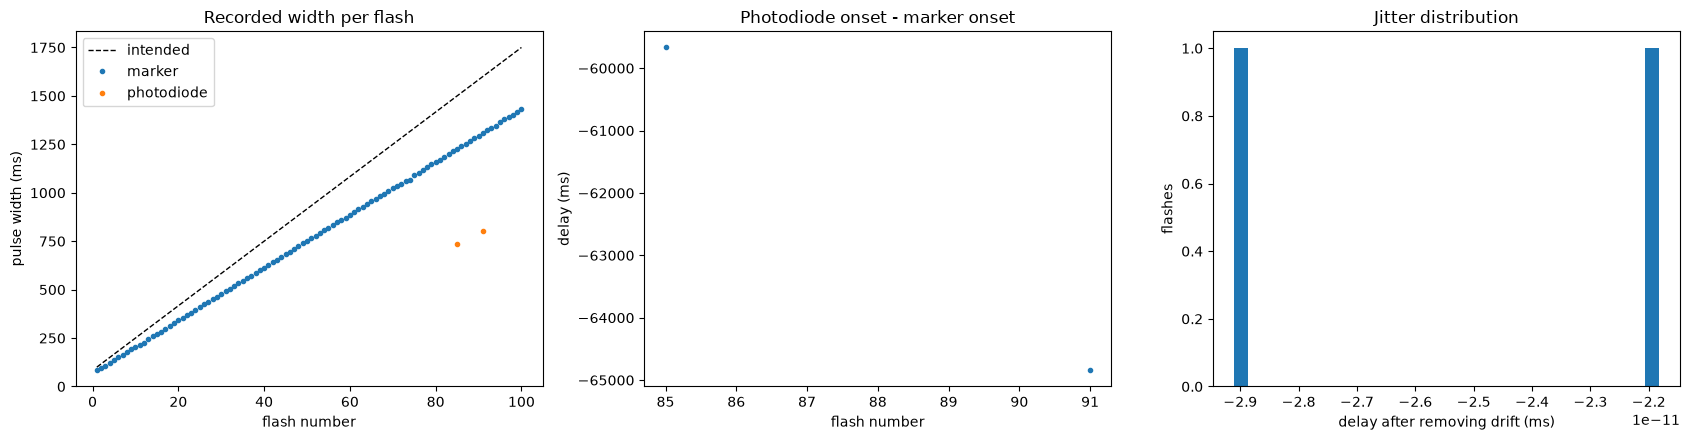

In [4]:
d = pairs.delay_ms
slope, icpt = np.polyfit(pairs.onset_s_mk - pairs.onset_s_mk.iloc[0], d, 1)
detr = d - (icpt + slope * (pairs.onset_s_mk - pairs.onset_s_mk.iloc[0]))
print("=== delay = photodiode onset - marker onset of the SAME flash (positive: light after marker) ===")
print(f"  LATENCY  mean {d.mean():9.2f} ms   median {d.median():9.2f} ms")
print(f"  first 5 flashes {d.iloc[:5].mean():9.2f} ms   last 5 flashes {d.iloc[-5:].mean():9.2f} ms")
print(f"  DRIFT    {slope * 60:+.2f} ms per minute ({d.iloc[-1] - d.iloc[0]:+.1f} ms from first to last paired flash)")
print(f"  JITTER   SD {d.std():.2f} ms raw   |   SD {detr.std():.2f} ms after removing the drift")
print(f"  resolution: 1 sample = {1000 / fs:.2f} ms")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(mk.flash, mk.intended_ms, "k--", lw=1, label="intended")
ax[0].plot(mk.flash, mk.width_ms, ".", label="marker")
ax[0].plot(pairs.flash, pairs.width_ms_pd, ".", label="photodiode")
ax[0].set(xlabel="flash number", ylabel="pulse width (ms)", title="Recorded width per flash"); ax[0].legend()
ax[1].plot(pairs.flash, d, ".")
ax[1].set(xlabel="flash number", ylabel="delay (ms)", title="Photodiode onset - marker onset")
ax[2].hist(detr, bins=30)
ax[2].set(xlabel="delay after removing drift (ms)", ylabel="flashes", title="Jitter distribution")
plt.tight_layout(); plt.show()

# Cell 5

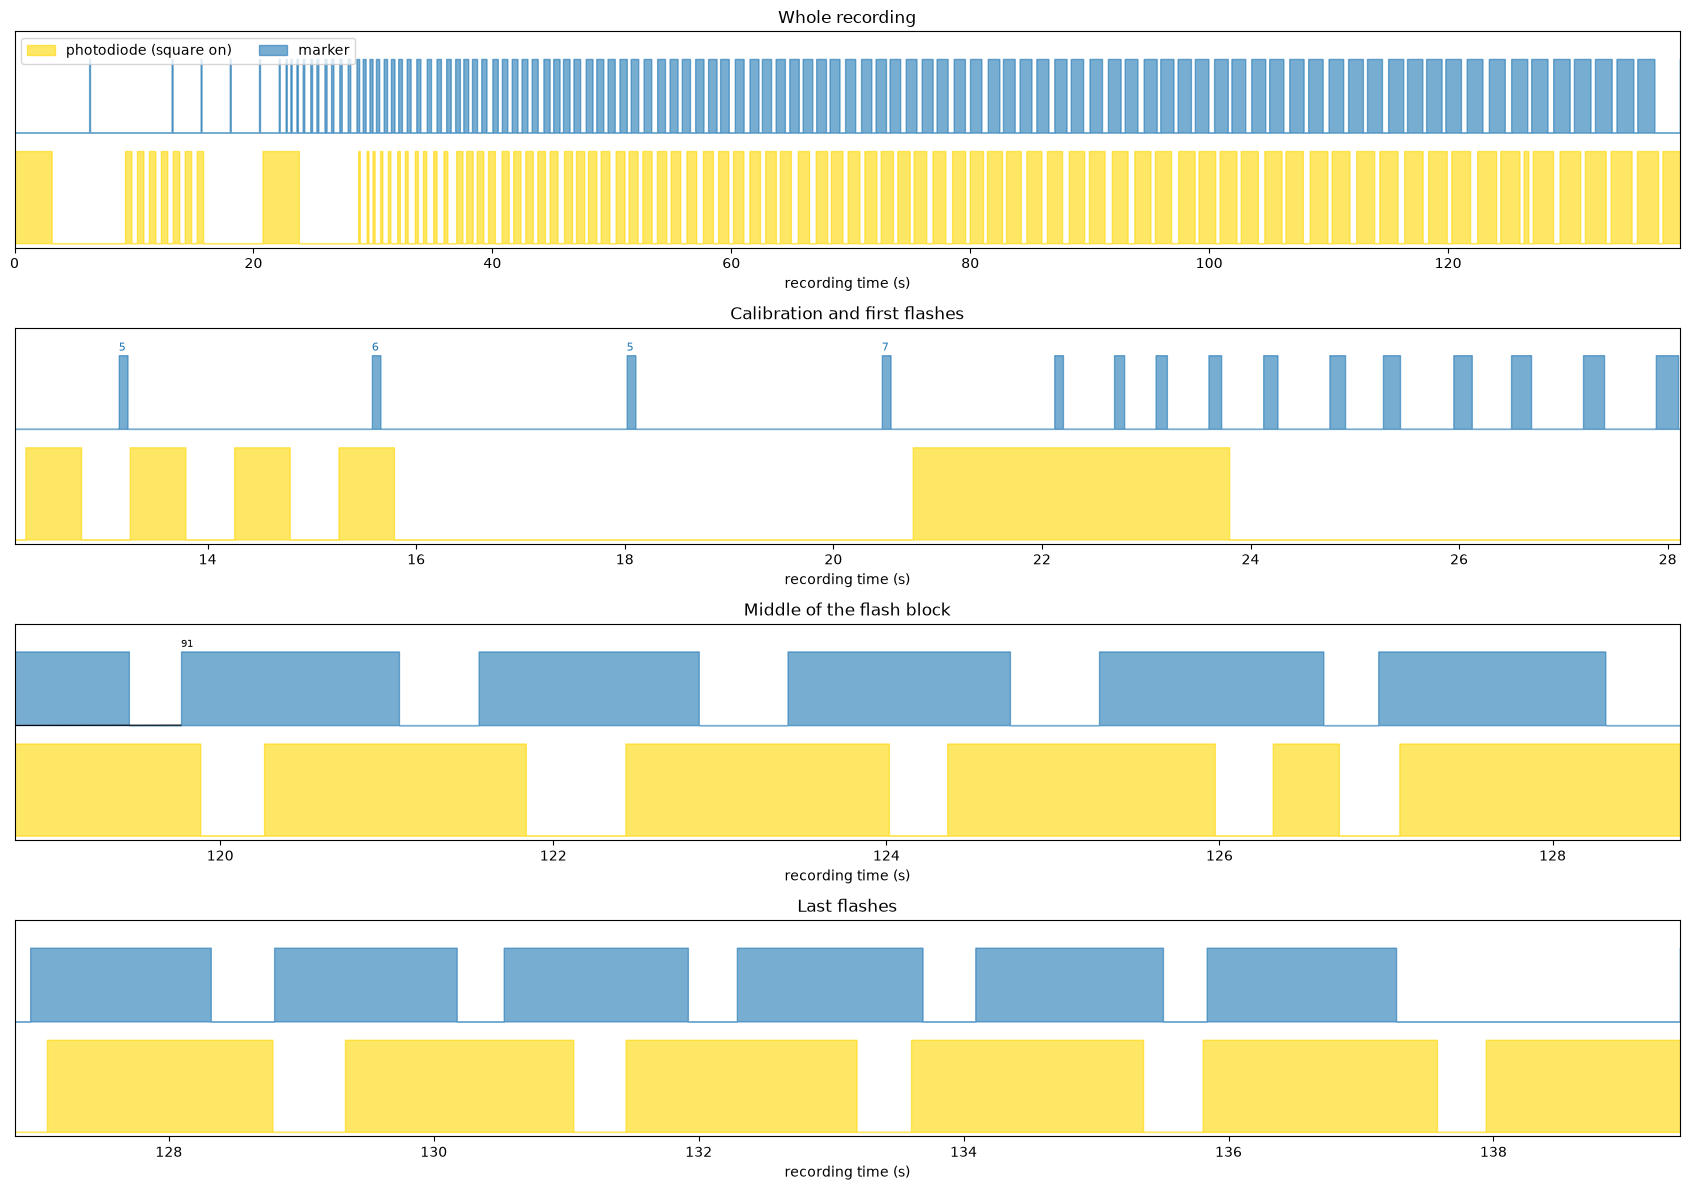

In [5]:
photo01 = square_on.astype(int)
mid = pairs.onset_s_mk.iloc[len(pairs) // 2]
windows = [("Whole recording", t[0], t[-1]),
           ("Calibration and first flashes", ev.loc[ev.code == CAL_DARK, "onset_s"].min() - 1, mk.onset_s.iloc[0] + 6),
           ("Middle of the flash block", mid - 1, mid + 9),
           ("Last flashes", mk.onset_s.iloc[-1] - 9, min(t[-1], mk.onset_s.iloc[-1] + 4))]
fig, axes = plt.subplots(len(windows), 1, figsize=(17, 3 * len(windows)))
for ax, (title, t0, t1) in zip(axes, windows):
    w = (t >= t0) & (t <= t1)
    ax.fill_between(t[w], 0, photo01[w], step="post", color="gold", alpha=0.6, label="photodiode (square on)")
    ax.fill_between(t[w], 1.2, 1.2 + (marker[w] > 0) * 0.8, step="post", color="tab:blue", alpha=0.6, label="marker")
    if t1 - t0 < 60:
        for _, e in ev[(ev.onset_s >= t0) & (ev.onset_s <= t1) & (ev.code != FLASH_CODE)].iterrows():
            ax.text(e.onset_s, 2.05, str(int(e.code)), color="tab:blue", fontsize=8)
        for _, p in pairs[(pairs.onset_s_mk >= t0) & (pairs.onset_s_mk <= t1)].iterrows():
            ax.plot([p.onset_s_mk, p.onset_s_pd], [1.2, 1.0], "k-", lw=0.8)
            ax.text(p.onset_s_mk, 2.05, str(int(p.flash)), fontsize=7)
    ax.set(title=title, xlim=(t0, t1), ylim=(-0.05, 2.3), yticks=[], xlabel="recording time (s)")
axes[0].legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()